# 03 - Exploratory Analysis

**Purpose:** Here we will verify that the New Orleans subset can support community-attention forecasting.

We will check the conditions needed for the final TS + SNA + NLP workflow: monthly history, active businesses, active reviewers, category context, and disruption periods.

In [1]:
# Configure paths and plotting defaults for exploratory figures.
from pathlib import Path
import csv
import json
from collections import Counter
from datetime import datetime, timezone

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_YELP_DIR = DATA_DIR / "raw" / "yelp"
INTERIM_DIR = DATA_DIR / "interim"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

BUSINESS_PATH = RAW_YELP_DIR / "yelp_academic_dataset_business.json"
REVIEW_PATH = RAW_YELP_DIR / "yelp_academic_dataset_review.json"
USER_PATH = RAW_YELP_DIR / "yelp_academic_dataset_user.json"

OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
INTERIM_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT.name}")

Project root: community-forecasting-yelp


In [2]:
# New Orleans files
CITY_INTERIM_DIR = INTERIM_DIR / "new_orleans"
BUSINESSES_PATH = CITY_INTERIM_DIR / "businesses.jsonl"
REVIEWS_PATH = CITY_INTERIM_DIR / "reviews.jsonl"
USERS_PATH = CITY_INTERIM_DIR / "users.jsonl"
SUMMARY_PATH = CITY_INTERIM_DIR / "summary.json"

# Load summary
with SUMMARY_PATH.open("r", encoding="utf-8") as file:
    summary = json.load(file)

summary

{'target_city': 'New Orleans',
 'target_state': 'LA',
 'dataset_slug': 'new_orleans',
 'created_at_utc': '2026-06-04T18:44:15.182841+00:00',
 'business_count': 6215,
 'review_count': 635521,
 'unique_reviewing_user_count': 245421,
 'matched_user_profile_count': 245419,
 'min_review_date': '2005-03-14 18:07:51',
 'max_review_date': '2022-01-19 19:47:59',
 'outputs': {'businesses': 'data\\interim\\new_orleans\\businesses.jsonl',
  'reviews': 'data\\interim\\new_orleans\\reviews.jsonl',
  'users': 'data\\interim\\new_orleans\\users.jsonl'}}

## Questions

- Is there enough monthly history for forecasting?
- How concentrated is attention across businesses?
- How sparse is local user activity?
- Which categories shape the local Yelp ecosystem?
- What design choices follow from these patterns?

In [3]:
# Read JSONL records
def iter_jsonl(path):
    with path.open("r", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            try:
                yield json.loads(line)
            except json.JSONDecodeError as exc:
                raise ValueError(f"Invalid JSON in {path} at line {line_number}") from exc

## Attention Concentration

let's measure how review attention is distributed across businesses.

In [4]:
# Count reviews
review_year_counts = Counter()
review_month_counts = Counter()
business_review_counts = Counter()
user_review_counts = Counter()

for record in iter_jsonl(REVIEWS_PATH):
    date_text = record.get("date", "")
    if len(date_text) >= 7:
        review_year_counts[date_text[:4]] += 1
        review_month_counts[date_text[:7]] += 1
    business_review_counts[record["business_id"]] += 1
    user_review_counts[record["user_id"]] += 1


# Reviews by year
print("Review counts by year:")
for year, count in sorted(review_year_counts.items()):
    print(f"{year}: {count:,}")


# Top businesses
print("\nMost reviewed New Orleans businesses by review count:")
for business_id, count in business_review_counts.most_common(10):
    print(f"{business_id}: {count:,}")


# Top reviewers
print("\nMost active reviewers in subset:")
for user_id, count in user_review_counts.most_common(10):
    print(f"{user_id}: {count:,}")

Review counts by year:
2005: 291
2006: 298
2007: 1,233
2008: 3,192
2009: 6,721
2010: 14,150
2011: 26,391
2012: 28,906
2013: 38,107
2014: 51,148
2015: 66,758
2016: 70,981
2017: 74,184
2018: 88,584
2019: 85,148
2020: 35,265
2021: 41,942
2022: 2,222

Most reviewed New Orleans businesses by review count:
_ab50qdWOk0DdB6XOrBitw: 7,673
ac1AeYqs8Z4_e2X5M3if2A: 7,516
oBNrLz4EDhiscSlbOl8uAw: 5,264
iSRTaT9WngzB8JJ2YKJUig: 5,254
VQcCL9PiNL_wkGf-uF3fjg: 5,146
_C7QiQQc47AOEv4PE3Kong: 4,969
GBTPC53ZrG1ZBY3DT8Mbcw: 4,661
6a4gLLFSgr-Q6CZXDLzBGQ: 4,480
VaO-VW3e1kARkU9bP1E7Fw: 4,034
qb28j-FNX1_6xm7u372TZA: 3,971

Most active reviewers in subset:
0Igx-a1wAstiBDerGxXk2A: 1,420
Xw7ZjaGfr0WNVt6s_5KZfA: 1,237
1HM81n6n4iPIFU5d2Lokhw: 1,077
CfX4sTIFFNaRchNswqhVfg: 835
E4BsVQnG5zetbwv2x8QIWg: 756
0G-QF457q_0Z_jKqh6xWiA: 548
iT1AA74QFn_a0Xq9-ggSGA: 461
5tXRxr4T24Awl7vjyCvIcQ: 440
riWDgbauId8TK7YFVgMNJw: 418
Ase_kJIYuT6yOsqqVPuWUA: 417


In [5]:
# Count categories
category_counts = Counter()

for record in iter_jsonl(BUSINESSES_PATH):
    categories = record.get("categories") or ""
    for category in categories.split(","):
        category = category.strip()
        if category:
            category_counts[category] += 1


# Top categories
print("Top business categories:")
for category, count in category_counts.most_common(25):
    print(f"{category:<35} {count:>6}")

Top business categories:
Restaurants                           2261
Food                                  1263
Shopping                              1028
Nightlife                              942
Bars                                   826
Event Planning & Services              656
Hotels & Travel                        620
Arts & Entertainment                   539
Beauty & Spas                          437
Cajun/Creole                           402
Breakfast & Brunch                     367
Sandwiches                             354
Seafood                                332
American (New)                         324
Local Services                         322
Coffee & Tea                           318
Fashion                                312
Active Life                            302
American (Traditional)                 299
Hotels                                 296
Home Services                          282
Health & Medical                       277
Automotive                   

## Activity Structure

In [6]:
# Summary stats
from statistics import mean, median

business_review_values = list(business_review_counts.values())
user_review_values = list(user_review_counts.values())


# Threshold count
def count_at_least(values, threshold):
    return sum(value >= threshold for value in values)


# Business distribution
print("Business review distribution")
print(f"Businesses with reviews: {len(business_review_values):,}")
print(f"Mean reviews per business: {mean(business_review_values):.2f}")
print(f"Median reviews per business: {median(business_review_values):,.0f}")
print(f"Maximum reviews for one business: {max(business_review_values):,}")

for threshold in [10, 25, 50, 100, 250, 500, 1000]:
    print(f"Businesses with at least {threshold:>4} reviews: {count_at_least(business_review_values, threshold):,}")

review_total = sum(business_review_values)
top_10_business_reviews = sum(count for _, count in business_review_counts.most_common(10))
top_100_business_reviews = sum(count for _, count in business_review_counts.most_common(100))

print(f"Top 10 businesses' share of reviews: {top_10_business_reviews / review_total:.2%}")
print(f"Top 100 businesses' share of reviews: {top_100_business_reviews / review_total:.2%}")


# User distribution
print("\nUser review distribution")
print(f"Reviewing users: {len(user_review_values):,}")
print(f"Mean reviews per user: {mean(user_review_values):.2f}")
print(f"Median reviews per user: {median(user_review_values):,.0f}")
print(f"Maximum reviews by one user: {max(user_review_values):,}")

for threshold in [2, 3, 5, 10, 25, 50, 100]:
    print(f"Users with at least {threshold:>3} reviews: {count_at_least(user_review_values, threshold):,}")

top_10_user_reviews = sum(count for _, count in user_review_counts.most_common(10))
top_100_user_reviews = sum(count for _, count in user_review_counts.most_common(100))

print(f"Top 10 users' share of reviews: {top_10_user_reviews / review_total:.2%}")
print(f"Top 100 users' share of reviews: {top_100_user_reviews / review_total:.2%}")

Business review distribution
Businesses with reviews: 6,215
Mean reviews per business: 102.26
Median reviews per business: 22
Maximum reviews for one business: 7,673
Businesses with at least   10 reviews: 4,649
Businesses with at least   25 reviews: 2,952
Businesses with at least   50 reviews: 1,962
Businesses with at least  100 reviews: 1,225
Businesses with at least  250 reviews: 547
Businesses with at least  500 reviews: 259
Businesses with at least 1000 reviews: 89
Top 10 businesses' share of reviews: 8.33%
Top 100 businesses' share of reviews: 31.46%

User review distribution
Reviewing users: 245,421
Mean reviews per user: 2.59
Median reviews per user: 1
Maximum reviews by one user: 1,420
Users with at least   2 reviews: 96,699
Users with at least   3 reviews: 56,380
Users with at least   5 reviews: 26,598
Users with at least  10 reviews: 8,204
Users with at least  25 reviews: 1,666
Users with at least  50 reviews: 585
Users with at least 100 reviews: 180
Top 10 users' share of re

Review activity is highly uneven: the average business has about **102 reviews**, the median has **22**, and the top **100** businesses account for about **31.46%** of all New Orleans reviews.

This justifies an active-business cohort and motivates and building an attention-pulse target. Raw review volume mostly reflects established popularity; attention pulses focus on unusual short-term visibility increases relative to each business's own recent baseline.

User activity is sparse, so SNA features should focus on connected reviewers rather than all users equally.

In [7]:
months = sorted(review_month_counts)
pre_covid_months = [month for month in months if month < "2020-01"]
forecast_scope_months = [month for month in months if "2015-01" <= month < "2020-01"]
peak_month, peak_count = max((item for item in review_month_counts.items() if item[0] < "2020-01"), key=lambda item: item[1])

print(f"Observed raw months: {len(months)}")
print(f"First observed raw month: {months[0]}")
print(f"Last observed raw month: {months[-1]}")
print(f"Final forecasting scope: 2015-01 to 2019-12")
print(f"Average monthly reviews in final pre-COVID scope: {mean(review_month_counts[m] for m in forecast_scope_months):,.2f}")
print(f"Peak pre-COVID month: {peak_month} with {peak_count:,} reviews")


Observed raw months: 202
First observed raw month: 2005-03
Last observed raw month: 2022-01
Final forecasting scope: 2015-01 to 2019-12
Average monthly reviews in final pre-COVID scope: 6,427.58
Peak pre-COVID month: 2019-03 with 9,396 reviews


In [8]:
# Plot setup
import matplotlib.pyplot as plt
from datetime import datetime

FIGURES_DIR = OUTPUTS_DIR / "figures" / "eda"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Plot style
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Figure paths
figure_paths = {}

### Review Activity Over Time

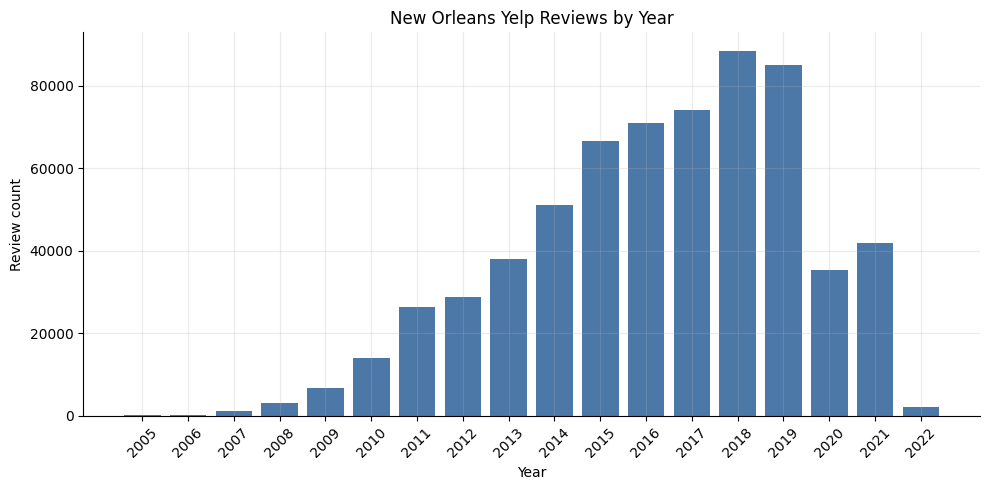

outputs\figures\eda\reviews_by_year.png


In [9]:
# Prepare yearly data
years = sorted(review_year_counts)
year_values = [review_year_counts[year] for year in years]

# Plot yearly reviews
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(years, year_values, color="#4C78A8")
ax.set_title("New Orleans Yelp Reviews by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Review count")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()

# Save figure
path = FIGURES_DIR / "reviews_by_year.png"
fig.savefig(path, dpi=160)
plt.show()
plt.close(fig)

# Store path
figure_paths["reviews_by_year"] = path
print(path.relative_to(PROJECT_ROOT))

Review counts rise steadily from 2005, peak in 2018-2019, then drop sharply in 2020, likely due to COVID-19. The small 2021 rebound suggests partial recovery, while 2022 appears too low and may be incomplete.

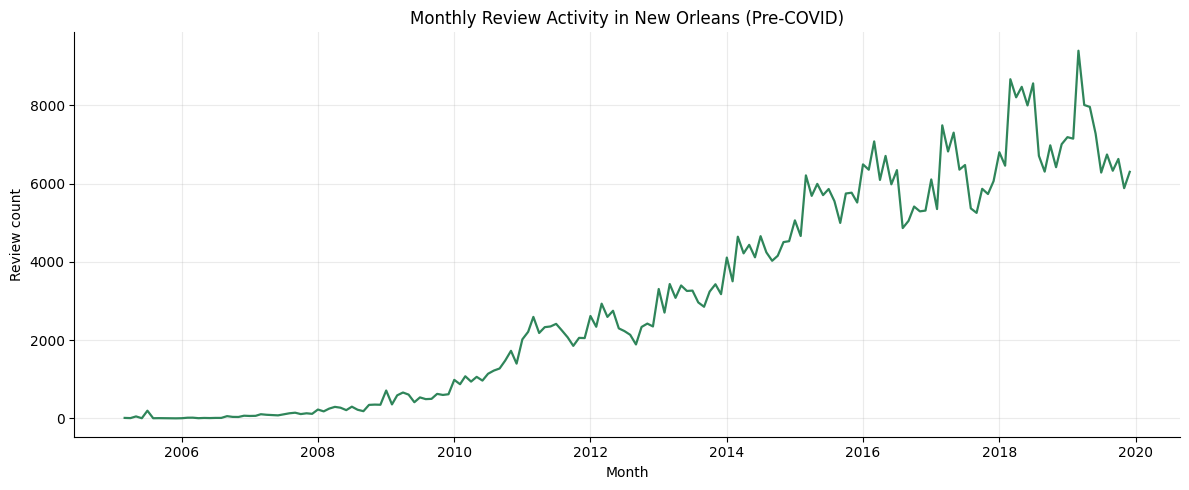

outputs\figures\eda\monthly_review_activity.png


In [10]:
# Prepare monthly data
month_items = sorted(
    (datetime.strptime(month, "%Y-%m"), count)
    for month, count in review_month_counts.items()
    if month < "2020-01"
)
month_dates = [item[0] for item in month_items]
month_values = [item[1] for item in month_items]

# Plot monthly reviews
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(month_dates, month_values, color="#2F855A", linewidth=1.6)
ax.set_title("Monthly Review Activity in New Orleans (Pre-COVID)")
ax.set_xlabel("Month")
ax.set_ylabel("Review count")
fig.tight_layout()

# Save figure
path = FIGURES_DIR / "monthly_review_activity.png"
fig.savefig(path, dpi=160)
plt.show()
plt.close(fig)

# Store path
figure_paths["monthly_review_activity"] = path
print(path.relative_to(PROJECT_ROOT))

This monthly view adds detail to the yearly pattern: review activity grew unevenly, with clear short-term fluctuations around the rising trend. The repeated peaks and dips suggest seasonality or event-driven changes in Yelp engagement before COVID.

### Business Review Concentration

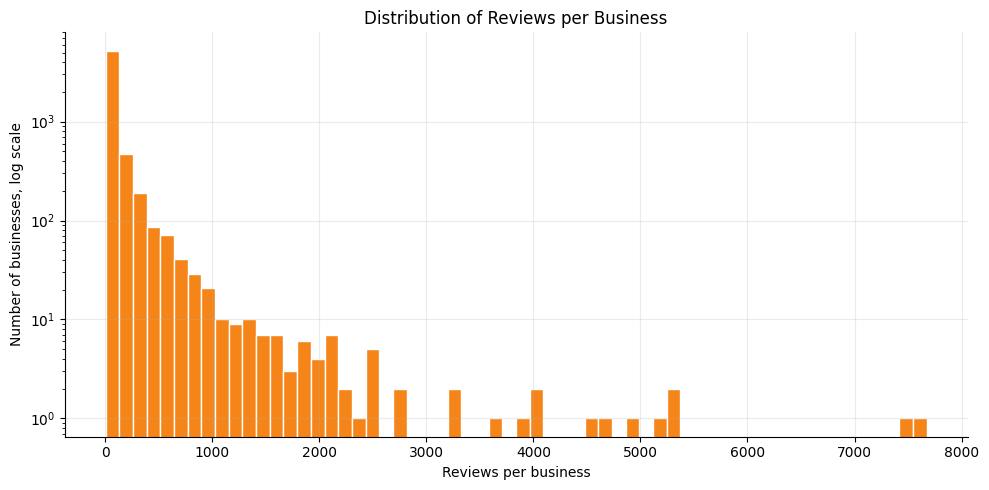

outputs\figures\eda\business_review_distribution.png


In [11]:
# Prepare business counts
business_counts_sorted = sorted(business_review_values, reverse=True)

# Plot business reviews
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(business_review_values, bins=60, color="#F58518", edgecolor="white")
ax.set_yscale("log")
ax.set_title("Distribution of Reviews per Business")
ax.set_xlabel("Reviews per business")
ax.set_ylabel("Number of businesses, log scale")
fig.tight_layout()

# Save figure
path = FIGURES_DIR / "business_review_distribution.png"
fig.savefig(path, dpi=160)
plt.show()
plt.close(fig)

# Store path
figure_paths["business_review_distribution"] = path
print(path.relative_to(PROJECT_ROOT))

This figure shows that review attention is highly uneven across businesses. Most businesses receive relatively few reviews, while a small number attract thousands, creating a long-tail distribution. This suggests that a few highly visible or popular businesses dominate Yelp activity.

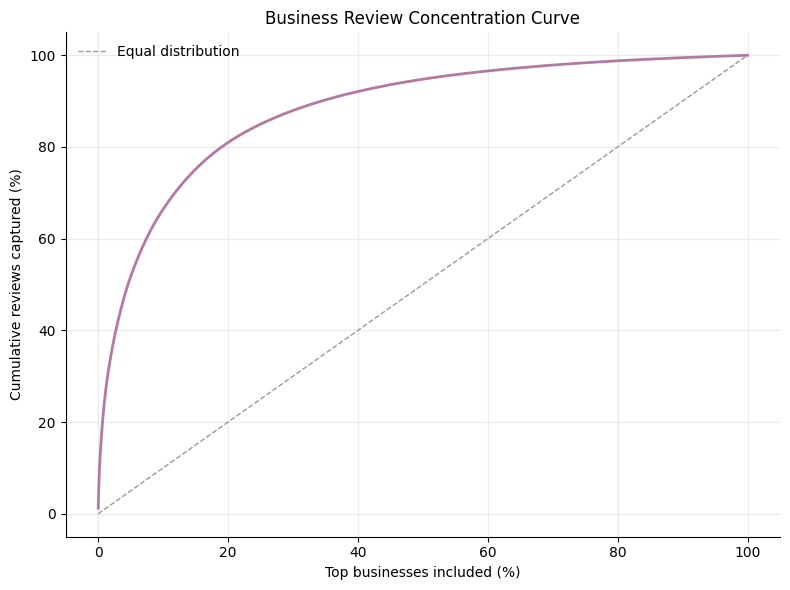

outputs\figures\eda\business_review_concentration.png


In [12]:
# Compute concentration
total_business_reviews = sum(business_counts_sorted)
cumulative_reviews = []
running_total = 0

for count in business_counts_sorted:
    running_total += count
    cumulative_reviews.append(running_total / total_business_reviews * 100)

percent_businesses = [(index + 1) / len(business_counts_sorted) * 100 for index in range(len(business_counts_sorted))]

# Plot concentration curve
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(percent_businesses, cumulative_reviews, color="#B279A2", linewidth=2)
ax.plot([0, 100], [0, 100], color="#999999", linestyle="--", linewidth=1, label="Equal distribution")
ax.set_title("Business Review Concentration Curve")
ax.set_xlabel("Top businesses included (%)")
ax.set_ylabel("Cumulative reviews captured (%)")
ax.legend(frameon=False)
fig.tight_layout()

# Save figure
path = FIGURES_DIR / "business_review_concentration.png"
fig.savefig(path, dpi=160)
plt.show()
plt.close(fig)

# Store path
figure_paths["business_review_concentration"] = path
print(path.relative_to(PROJECT_ROOT))

This curve quantifies the imbalance shown earlier: a small share of businesses captures most reviews. For example, roughly the top 20% of businesses account for over 80% of reviews, far above the equal-distribution line. This confirms strong concentration in Yelp visibility.

### User Activity Sparsity

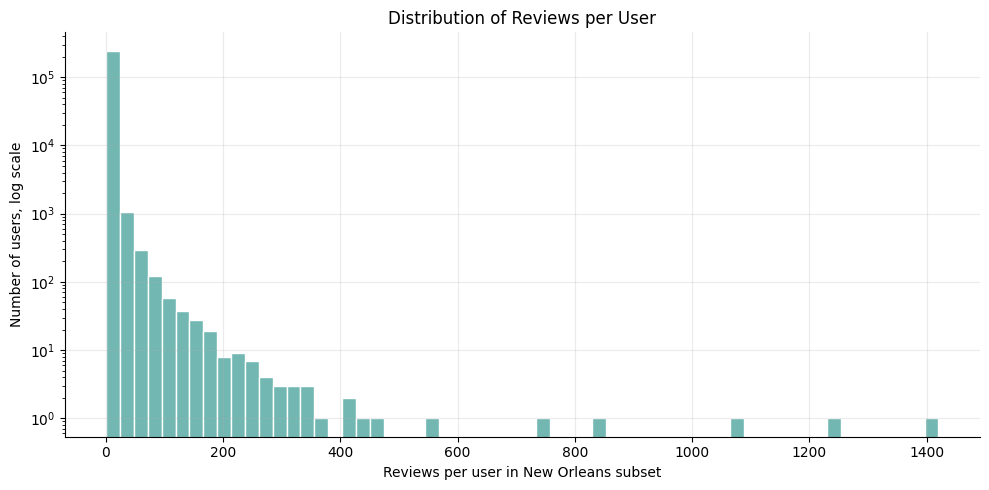

outputs\figures\eda\user_review_distribution.png


In [13]:
# Plot user reviews
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(user_review_values, bins=60, color="#72B7B2", edgecolor="white")
ax.set_yscale("log")
ax.set_title("Distribution of Reviews per User")
ax.set_xlabel("Reviews per user in New Orleans subset")
ax.set_ylabel("Number of users, log scale")
fig.tight_layout()

# Save figure
path = FIGURES_DIR / "user_review_distribution.png"
fig.savefig(path, dpi=160)
plt.show()
plt.close(fig)

# Store path
figure_paths["user_review_distribution"] = path
print(path.relative_to(PROJECT_ROOT))

User activity is also highly skewed: most users write only a few reviews, while a very small number contribute hundreds or even over 1,000. This shows that Yelp content is shaped not only by popular businesses, but also by a small group of highly active reviewers.

### Category Mix

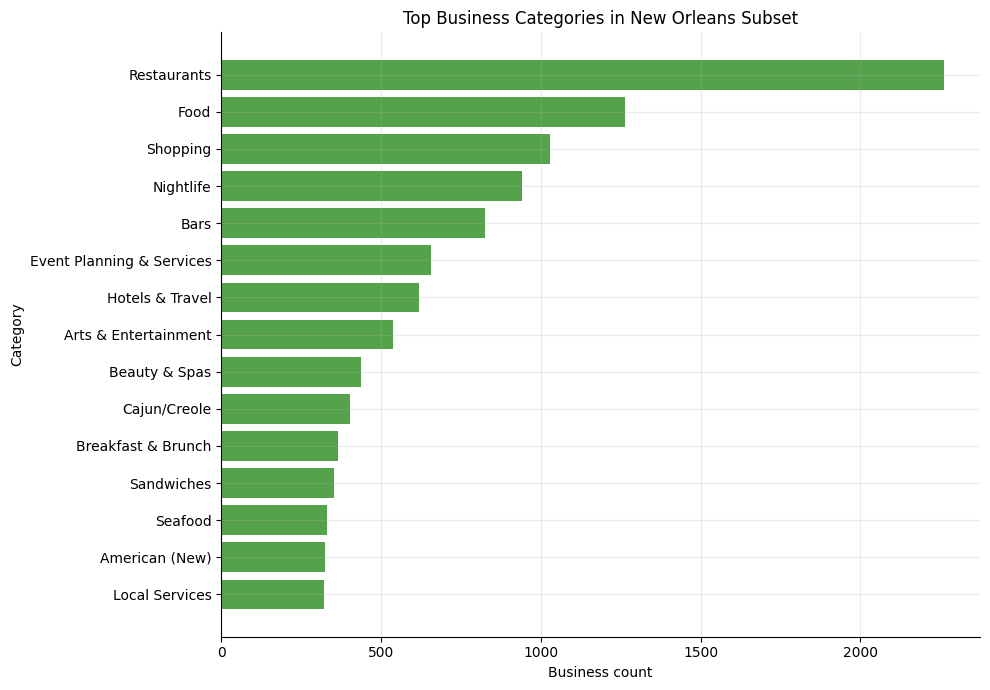

outputs\figures\eda\top_business_categories.png


In [14]:
# Prepare top categories
top_categories = category_counts.most_common(15)
categories = [category for category, _ in reversed(top_categories)]
category_values = [count for _, count in reversed(top_categories)]

# Plot categories
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(categories, category_values, color="#54A24B")
ax.set_title("Top Business Categories in New Orleans Subset")
ax.set_xlabel("Business count")
ax.set_ylabel("Category")
fig.tight_layout()

# Save figure
path = FIGURES_DIR / "top_business_categories.png"
fig.savefig(path, dpi=160)
plt.show()
plt.close(fig)

# Store path
figure_paths["top_business_categories"] = path
print(path.relative_to(PROJECT_ROOT))

The dataset is strongly centered on hospitality and consumer-facing services. Restaurants dominate by far, followed by food, shopping, nightlife, and bars, which fits New Orleans’ tourism and dining-oriented economy. This means later review patterns should be interpreted mainly through these sectors.

### Rating Distribution

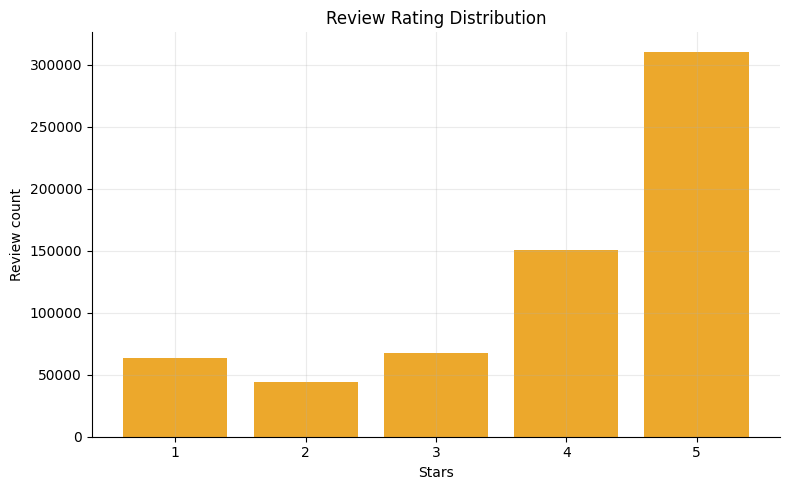

outputs\figures\eda\rating_distribution.png


In [15]:
# Count ratings
star_counts = Counter()
for record in iter_jsonl(REVIEWS_PATH):
    star_counts[int(record["stars"])] += 1

stars = sorted(star_counts)
star_values = [star_counts[star] for star in stars]

# Plot ratings
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([str(star) for star in stars], star_values, color="#ECA82C")
ax.set_title("Review Rating Distribution")
ax.set_xlabel("Stars")
ax.set_ylabel("Review count")
fig.tight_layout()

# Save figure
path = FIGURES_DIR / "rating_distribution.png"
fig.savefig(path, dpi=160)
plt.show()
plt.close(fig)

# Store path
figure_paths["rating_distribution"] = path
print(path.relative_to(PROJECT_ROOT))

Ratings are strongly positive, with 5-star reviews dominating and 4-star reviews also common. Lower ratings are much less frequent, suggesting Yelp reviews in this subset are skewed toward favorable experiences rather than evenly spread across satisfaction levels.

## EDA Takeaways

- The dataset is large enough for community-attention forecasting.
- Review activity is concentrated, so the forecasting cohort should use an activity threshold.
- User activity is sparse, so SNA should focus on active and connected reviewers.
- The final forecasting scope should use chronological splits and a pre-COVID test period.
